# Assignment 3 - Building a Simplified Transformer for Sentiment Analysis

This file implement simplified Transformer from scratch to classify the perform sentiment analysis on IMDb dataset..

In [ ]:
# import relevant libraries
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader # to prepare for DataLoader
from datasets import load_dataset
from collections import Counter

from train_utils import train, test # Shared training/testing function across all notebook file
from transformer_encoder import TransformerEncoder # Shared Transformer encoder architecture across all notebook file
from tokenisation_utils import tokenise_words, build_vocabulary, compute_oov_rate, tokenise_function # Shared frequency-based tokenisation across all notebook file


### 1. Load The IMDb Dataset, Preprocessing, and Dataset Handling

In [2]:
# load the dataset
imdb_dataset = load_dataset('stanfordnlp/imdb')

In [3]:
target_names = ['negative','positive'] # how can I know 0=negative, 1=positive?

In [4]:
# Count the label
train_label = list(imdb_dataset['train']['label'])
test_label = list(imdb_dataset['test']['label'])

In [5]:
count_train_label = Counter(train_label)
count_test_label = Counter(test_label)
print(f"The count of train label is:{count_train_label}")
print(f"\nThe count of test label is:{count_test_label}")

The count of train label is:Counter({0: 12500, 1: 12500})

The count of test label is:Counter({0: 12500, 1: 12500})


In [6]:
# Count the text length
train_length = []
test_length = []
for i in imdb_dataset['train']['text']:
    train_length.append(len(i))
for j in imdb_dataset['test']['text']:
    test_length.append(len(j))

print(f"The shortest train length (character) is {min(train_length)} chars.\nThe longest train length (character) is {max(train_length)} chars.")
print(f"\nThe shortest test length (character) is {min(test_length)} chars.\nThe longest test length (character) is {max(test_length)} chars.")

The shortest train length (character) is 52 chars.
The longest train length (character) is 13704 chars.

The shortest test length (character) is 32 chars.
The longest test length (character) is 12988 chars.


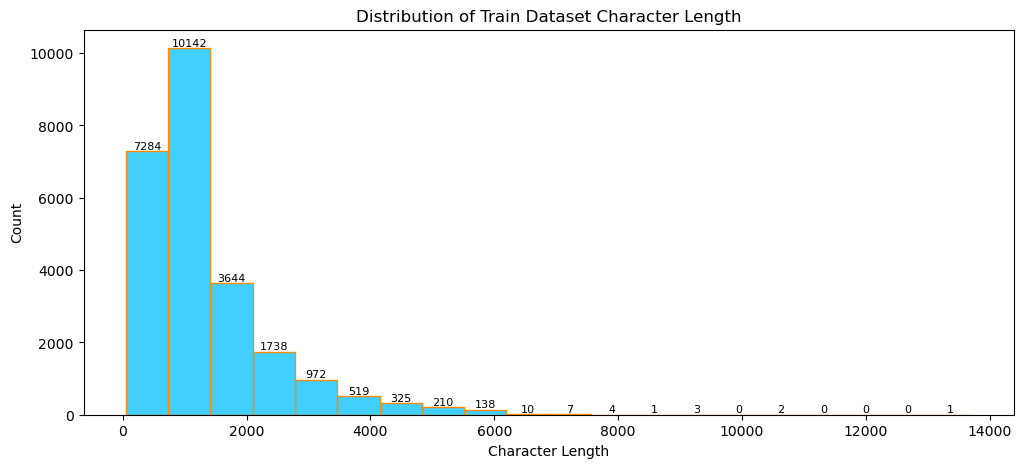

In [7]:
# visualise train dataset character length
plt.figure(figsize=(12,5))
plt.title("Distribution of Train Dataset Character Length")
plt.xlabel("Character Length")
sns_char_train = sns.histplot(data=train_length, bins=20, color='deepskyblue', edgecolor='darkorange')
sns_char_train.bar_label(sns_char_train.containers[0], fontsize=8)

plt.show()

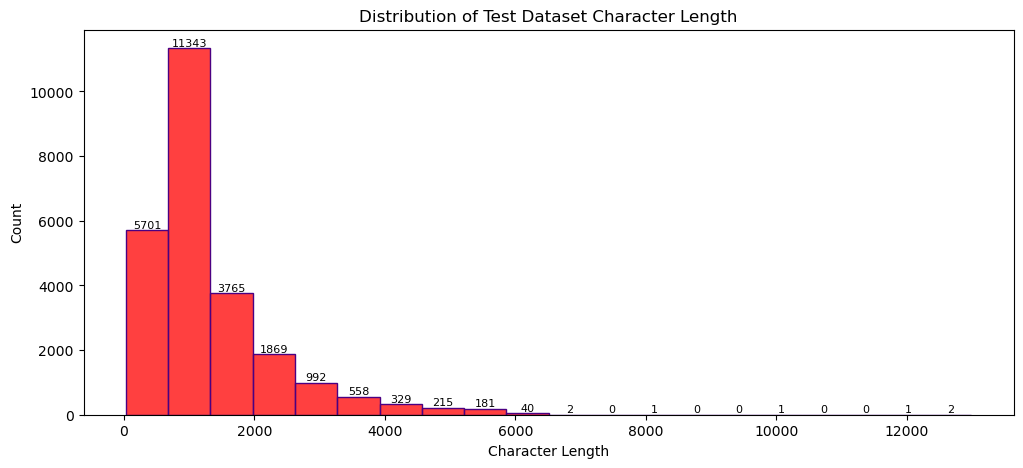

In [18]:
# visualise
plt.figure(figsize=(12,5))
plt.title("Distribution of Test Dataset Character Length")
plt.xlabel("Character Length")
sns_char_test = sns.histplot(data=test_length, bins=20, color='red', edgecolor='indigo')
sns_char_test.bar_label(sns_char_test.containers[0], fontsize=8)

plt.show()

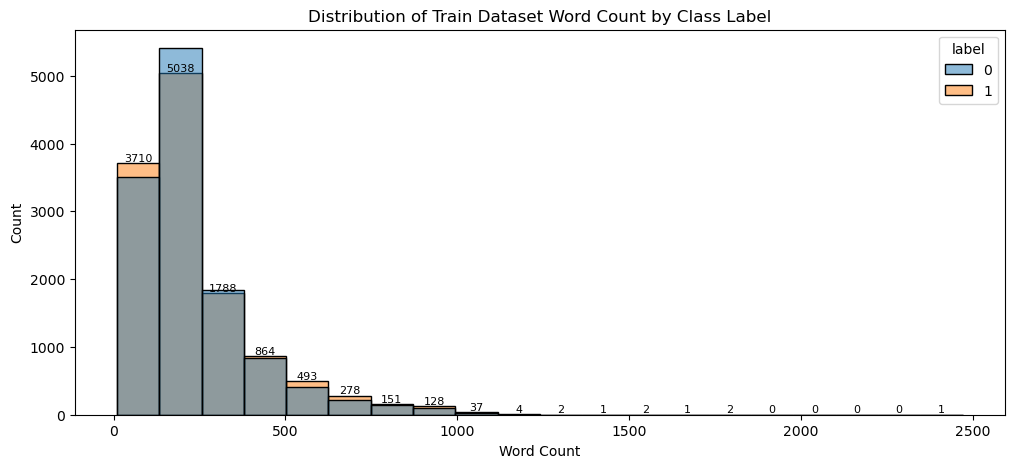

In [19]:
# Extract per words
train_word_counts = [len(text.split()) for text in imdb_dataset['train']['text']] # word count per review
train_word_labels = imdb_dataset['train']['label']

# Visualise length of words per class labels (histogram). Use class label as hue
plt.figure(figsize=(12,5))
plt.title("Distribution of Train Dataset Word Count by Class Label")
plt.xlabel("Word Count")
sns_word_train =  sns.histplot(
    data={'word_count': train_word_counts, 'label': train_word_labels},
    x='word_count',
    hue='label',
    bins=20,
    multiple='layer'
)
sns_word_train.bar_label(sns_word_train.containers[0], fontsize=8)
plt.show()

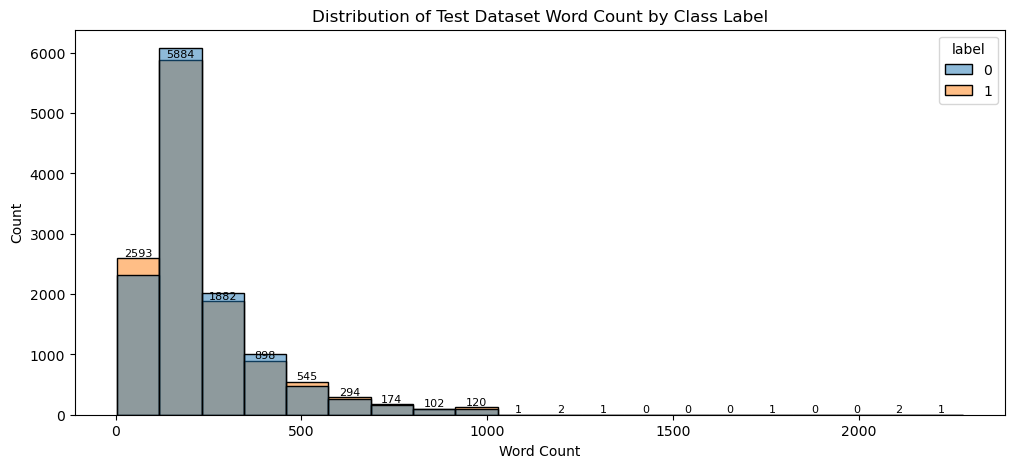

In [8]:
# Extract per words (test)
test_word_counts = [len(text.split()) for text in imdb_dataset['test']['text']] # word count per review
test_word_labels = imdb_dataset['test']['label']

# Visualise length of words per class labels (histogram). Use class label as hue
plt.figure(figsize=(12,5))
plt.title("Distribution of Test Dataset Word Count by Class Label")
plt.xlabel("Word Count")
sns_word_test = sns.histplot(
    data={'word_count': test_word_counts, 'label': test_word_labels},
    x='word_count',
    hue='label',
    bins=20,
    multiple='layer'
)

sns_word_test.bar_label(sns_word_test.containers[0], fontsize=8)
plt.show()

#### Build a word-frequency vocabulary

Instead of a pretrained BERT WordPiece tokeniser, this section builds a simple word-level vocabulary directly from the IMDb train corpus: count every word's frequency, then keep only the `custom_vocab_size` most frequent words. This matches the assignment's "simple word embedding layer" requirement more closely than a subword tokeniser. Words outside this vocabulary are mapped to `[UNK]` at tokenisation time.

In [9]:
# build a word-level vocabulary, keeping only the most frequent words
custom_vocab_size = 20000 # change this value to experiment with vocab capacity later

# build the vocabulary from the training corpus only (never the test set, to avoid leakage)
word_to_id = build_vocabulary(imdb_dataset["train"], vocab_size=custom_vocab_size)
pad_token_id = word_to_id["[PAD]"]
unk_token_id = word_to_id["[UNK]"]

print(f"Vocabulary size: {len(word_to_id)}")

Vocabulary size: 20000


In [10]:
train_oov_rate = compute_oov_rate(imdb_dataset["train"], word_to_id)
test_oov_rate = compute_oov_rate(imdb_dataset["test"], word_to_id)

print(f"Train OOV rate: {train_oov_rate:.2%}")
print(f"Test OOV rate: {test_oov_rate:.2%}")

Train OOV rate: 2.29%
Test OOV rate: 2.97%


In [11]:
# define the tokenisation function (manual word-to-id mapping, no HuggingFace tokeniser)
max_seq_length = 600

In [ ]:
# tokenise the dataset
tokenised_datasets = imdb_dataset.map( # map is used to apply a processing transformation
    lambda examples: tokenise_function(examples, word_to_id, unk_token_id, pad_token_id, max_seq_length),
    batched=True
)
# run the tokenise_function in batch. Tokenise text into words, maps each word to an id with word_to_id
# truncates/pads every sequence to max_seq_length


tokenised_datasets = tokenised_datasets.select_columns(["input_ids", "attention_mask", "label"])
# select.columns is used to drop everything excep the three columns that needed.

tokenised_datasets.set_format("torch") # return PyTorch tensors for further task


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [13]:
# create PyToch DataLoaders
train_dataloader = DataLoader(
    tokenised_datasets["train"],
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    tokenised_datasets["test"],
    batch_size=32,
    shuffle=False
)

93

In [14]:
# show information of the datasets per batch
for batch in train_dataloader:
    print("Input IDs shape:", batch["input_ids"].shape)          # [32, 512]
    print("Attention Mask shape:", batch["attention_mask"].shape)  # [32, 512]
    print("Labels shape:", batch["label"].shape)                 # [32]
    break

Input IDs shape: torch.Size([32, 600])
Attention Mask shape: torch.Size([32, 600])
Labels shape: torch.Size([32])


### 2. Transformers Implementation

**1. Architecture Requirements**
- **Input Embedding Layer**:
    - Convert input text to token embeddings using a simple word embedding layer.
    - Use torch.nn.Embedding or implement your own.
- **Positional Encoding**:
    - Add positional encodings to input embeddings to incorporate sequential information.
- **Self-Attention Mechanism**:
    - Implement scaled dot-product attention: $$\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) V$$
    - Use multi-head attention for richer feature representations.
- **Feedforward Network**:
    - Add a two-layer feedforward network with ReLU activation.
- **Classification Head**:
    - Use a fully connected layer to map the output of the Transformer to a binary label (positive or negative).
- **Architecture Summary**:
    - Input → Embedding → Positional Encoding → Multi-Head Attention → Feedforward → Classification Head → Output

**2. Forward Propagation**
- Implement tokenization, embedding, attention computation, and feedforward operations.
- Use softmax activation in the output layer for binary classification probabilities.

**3. Backward Propagation**
- Compute gradients for all weights using binary cross-entropy loss.
- Update weights using **Adam Optimizer**.

**4. Training Loop**
- Train the Transformer for **10** epochs with:
    - Batch size: **32**
    - Learning rate: **0.001**
- Use mini-batch processing.

**5. Evaluation**
- Evaluate the model on the IMDb test set.
- Calculate and report **accuracy, precision, recall, and F1-score**.

The encoder block of Transformers consist of (in order):
- Multi-head attention
- Residual connection and layer normalisation
- Fully connected feed-forward network
- Residual connection and layer normalisation


### 3. Training Phase

In [15]:
# detect the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [16]:
# instantiate the model
encoder = TransformerEncoder(
    num_layers=4, # number of encoder block
    d_model=64, # width of every token vector representation
    num_heads=4, # head dim is d_model / num_heads
    d_ff=256, # width of feed forward hidden layer
    input_vocab_size=len(word_to_id),
    max_seq_length=600,
    pad_token_id=pad_token_id,
    dropout=0.1
    )
encoder = encoder.to(device)

In [17]:
encoder

TransformerEncoder(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (enc_layers): ModuleList(
    (0-3): 4 x TransformerEncoderBlock(
      (mha): MultiHeadAttention(
        (wq): Linear(in_features=64, out_features=64, bias=True)
        (wk): Linear(in_features=64, out_features=64, bias=True)
        (wv): Linear(in_features=64, out_features=64, bias=True)
        (dense): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (classification): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [18]:
optimiser = torch.optim.Adam(encoder.parameters(), lr=0.001)
criterion = torch.nn.BCELoss()

Performing the training phase..
Epoch: 1/10 | Train Loss: 0.4982 | Val Loss: 0.3797
Epoch: 2/10 | Train Loss: 0.3841 | Val Loss: 0.3284
Epoch: 3/10 | Train Loss: 0.3361 | Val Loss: 0.2681
Epoch: 4/10 | Train Loss: 0.3023 | Val Loss: 0.2455
Epoch: 5/10 | Train Loss: 0.2800 | Val Loss: 0.2186
Epoch: 6/10 | Train Loss: 0.2621 | Val Loss: 0.2024
Epoch: 7/10 | Train Loss: 0.2461 | Val Loss: 0.1998
Epoch: 8/10 | Train Loss: 0.2298 | Val Loss: 0.1833
Epoch: 9/10 | Train Loss: 0.2186 | Val Loss: 0.1617
Epoch: 10/10 | Train Loss: 0.2053 | Val Loss: 0.1645
The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.97      0.91      0.94     12500
    positive       0.92      0.97      0.94     12500

    accuracy                           0.94     25000
   macro avg       0.94      0.94      0.94     25000
weighted avg       0.94      0.94      0.94     25000

The confusion matrix is:
----

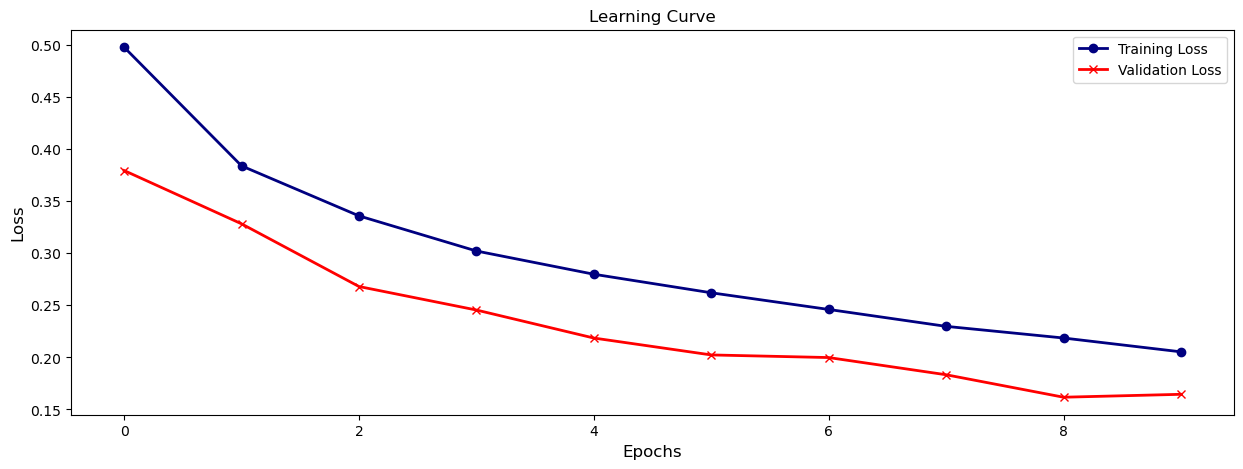

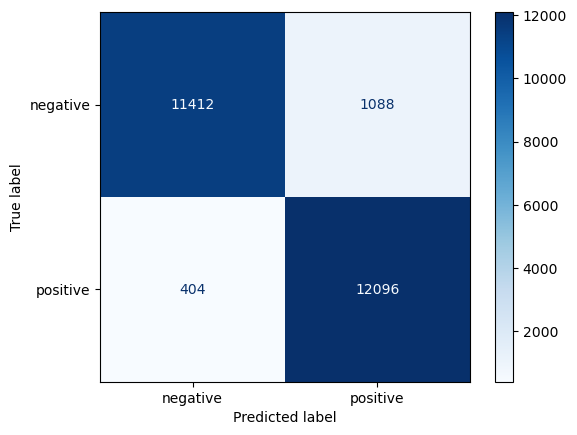


The training is completed!

Elapsed training time is: 1223.7869365215302 seconds (20.40 minutes)


In [19]:
# Call the training function
result = train(encoder, train_loader=train_dataloader, optimiser=optimiser, criterion=criterion, target_names=target_names, device=device, epochs=10)

The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.89      0.83      0.86     12500
    positive       0.84      0.90      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000


The confusion matrix is:
------------------------------------------------------------
[[10432  2068]
 [ 1273 11227]]


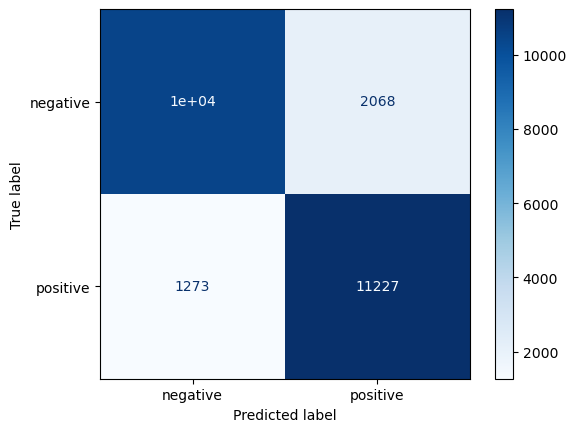


The testing is completed!


In [20]:
result = test(encoder, test_loader=test_dataloader, target_names=target_names, device=device, result_dict=result)

In [22]:
result['test']

{'negative': {'precision': 0.8912430585219991,
  'recall': 0.83456,
  'f1-score': 0.861970667217517,
  'support': 12500.0},
 'positive': {'precision': 0.8444528018051899,
  'recall': 0.89816,
  'f1-score': 0.8704787749563869,
  'support': 12500.0},
 'accuracy': 0.86636,
 'macro avg': {'precision': 0.8678479301635945,
  'recall': 0.86636,
  'f1-score': 0.866224721086952,
  'support': 25000.0},
 'weighted avg': {'precision': 0.8678479301635946,
  'recall': 0.86636,
  'f1-score': 0.8662247210869519,
  'support': 25000.0}}